# Beginner Workshop: EHR Modeling with a Synthetic MIMIC-IV Cohort

**Audience:** learners with basic Python knowledge who are new to clinical informatics and machine learning.  
**Duration:** approximately 3–4 hours, including discussion and exercises.

## Learning objectives

By the end of this workshop, participants should be able to:

1. Explain why EHR data are stored across multiple long-format tables.
2. Connect `subject_id`, `hadm_id`, and `stay_id` without accidentally changing the cohort.
3. Distinguish source columns, derived predictors, and outcomes.
4. Define a prediction time and identify target leakage.
5. Explore demographics, comorbidities, missingness, laboratory values, and outcomes.
6. Build reproducible scikit-learn preprocessing pipelines for mixed clinical data.
7. Evaluate LOS regression and readmission classification with repeated cross-validation.
8. interpret permutation importance and linear-model coefficients cautiously.

> **Safety statement:** This notebook uses synthetic educational data. The data and models are not clinically validated and must not be used for patient care, triage, diagnosis, treatment, or operational decisions.


## Suggested teaching plan

| Section | Suggested time | Teaching emphasis |
|---|---:|---|
| EHR structure and cohort keys | 30 min | Patients are not the same as admissions or ICU stays |
| Data provenance and leakage | 30 min | Prediction timing comes before feature selection |
| EDA and data quality | 45 min | Missingness and distributions are part of the data-generating process |
| Regression | 40 min | Baselines, repeated CV, errors in days |
| Classification | 40 min | Imbalance, AUROC versus AUPRC, calibration |
| Interpretation and exercises | 30 min | Predictive association is not causality |


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import RepeatedKFold, RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
_here = Path.cwd()
PROJECT_ROOT = (_here.parent if _here.name == "notebooks" else _here) / "synthetic_cohort_100"
DATA_DIR = PROJECT_ROOT / "data"
TABLE_DIR = DATA_DIR / "synthetic_tables"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", context="notebook")
print(f"Project: {PROJECT_ROOT}")


Project: <repo>/synthetic_cohort_100


## 1. How MIMIC-style EHR tables relate

An EHR is not one spreadsheet. It is a set of tables at different levels:

- `patients`: one row per person; key = `subject_id`.
- `admissions`: one row per hospital encounter; keys = `subject_id`, `hadm_id`.
- `icustays`: one row per ICU stay; keys include `subject_id`, `hadm_id`, `stay_id`.
- `diagnoses_icd` and `procedures_icd`: multiple coded rows per admission.
- `labevents`: multiple laboratory measurements per admission.
- `chartevents`: high-frequency bedside observations, often associated with an ICU stay.
- `services`: service history, with potentially several transfers per admission.
- `inputevents`: ICU-administered fluids and medications.

The **grain** is what one row represents. Before joining, always state the grain of every table. A careless join of two one-to-many tables can create a many-to-many multiplication.


In [2]:
table_names = [
    "patients", "admissions", "icustays", "diagnoses_icd",
    "procedures_icd", "services", "labevents", "chartevents", "inputevents"
]
tables = {name: pd.read_csv(TABLE_DIR / f"{name}.csv") for name in table_names}

table_inventory = pd.DataFrame([
    {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "unique_subjects": df["subject_id"].nunique() if "subject_id" in df else np.nan,
        "unique_admissions": df["hadm_id"].nunique() if "hadm_id" in df else np.nan,
        "unique_icu_stays": df["stay_id"].nunique() if "stay_id" in df else np.nan,
    }
    for name, df in tables.items()
])
table_inventory


,table,rows,columns,unique_subjects,unique_admissions,unique_icu_stays
0,patients,100,6,100,NaN,NaN
1,admissions,120,16,100,120.0,NaN
2,icustays,37,8,37,37.0,37.0
3,diagnoses_icd,301,5,100,100.0,NaN
4,procedures_icd,209,6,78,78.0,NaN
5,services,168,5,100,100.0,NaN
6,labevents,951,16,100,100.0,NaN
7,chartevents,418,11,37,37.0,37.0
8,inputevents,8,26,8,8.0,8.0


In [3]:
# Inspect exact source-like column names. These have not been silently renamed.
for name in table_names:
    print(f"\n{name}:")
    print(tables[name].columns.tolist())



patients:
['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']

admissions:
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']

icustays:
['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los']

diagnoses_icd:
['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']

procedures_icd:
['subject_id', 'hadm_id', 'seq_num', 'chartdate', 'icd_code', 'icd_version']

services:
['subject_id', 'hadm_id', 'transfertime', 'prev_service', 'curr_service']

labevents:
['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid', 'order_provider_id', 'charttime', 'storetime', 'value', 'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority', 'comments']

chartevents:
['subject_id', 'hadm_id', 'stay_i

### Joining safely: aggregate first, then merge

The example below creates one row per admission. Each one-to-many table is aggregated to `hadm_id` **before** merging. We use `validate=` so pandas raises an error if the assumed relationship is wrong.

An inner join answers “which admissions occur in all participating tables?” and can silently remove patients. A left join retains the cohort on the left and represents absent rows as missing or zero, depending on the clinical meaning.


In [4]:
admissions = tables["admissions"].copy()
patients = tables["patients"].copy()

diagnosis_counts = (
    tables["diagnoses_icd"].groupby("hadm_id")
    .size().rename("diagnosis_row_count").reset_index()
)
procedure_counts = (
    tables["procedures_icd"].groupby("hadm_id")
    .size().rename("procedure_row_count").reset_index()
)
lab_counts = (
    tables["labevents"].groupby("hadm_id")
    .size().rename("laboratory_row_count").reset_index()
)

admission_level_example = (
    admissions
    .merge(patients[["subject_id", "gender", "anchor_age", "anchor_year"]],
           on="subject_id", how="left", validate="many_to_one")
    .merge(diagnosis_counts, on="hadm_id", how="left", validate="one_to_one")
    .merge(procedure_counts, on="hadm_id", how="left", validate="one_to_one")
    .merge(lab_counts, on="hadm_id", how="left", validate="one_to_one")
)

for col in ["diagnosis_row_count", "procedure_row_count", "laboratory_row_count"]:
    admission_level_example[col] = admission_level_example[col].fillna(0).astype(int)

print("Rows before merges:", len(admissions))
print("Rows after safe merges:", len(admission_level_example))
admission_level_example.head()


Rows before merges: 120
Rows after safe merges: 120


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,gender,anchor_age,anchor_year,diagnosis_row_count,procedure_row_count,laboratory_row_count
0,90000001,80000001,2150-01-27 00:00:00.000000000,2150-02-05 11:39:18.056777904,NaN,Eu Observation,P00000,Emergency Room,HOME,Medicare,ENGLISH,Single,White,2150-01-26 22:00:00.000000000,2150-01-26 23:40:00.000000000,0,M,45,2150,4,1,3
1,90000001,80001001,2150-03-01 11:39:18.056777904,2150-03-04 07:08:08.998025729,NaN,URGENT,P00000,EMERGENCY ROOM,HOME,Medicare,ENGLISH,Single,White,2150-03-01 10:39:18.056777904,2150-03-01 11:29:18.056777904,0,M,45,2150,0,0,0
2,90000002,80000002,2150-08-21 00:00:00.000000000,2150-08-22 14:25:33.835896558,NaN,Observation Admit,P00000,Transfer From Hospital,HOME,Medicare,ENGLISH,Widowed,White,2150-08-20 22:00:00.000000000,2150-08-20 23:40:00.000000000,0,F,83,2150,3,0,4
3,90000003,80000003,2150-07-16 00:00:00.000000000,2150-07-18 15:16:58.755000433,NaN,Surgical Same Day Admission,P00000,Physician Referral,HOME,Medicaid,ENGLISH,Single,White,2150-07-15 22:00:00.000000000,2150-07-15 23:40:00.000000000,0,M,46,2150,2,2,10
4,90000004,80000004,2150-05-12 00:00:00.000000000,2150-05-19 06:59:11.523911166,NaN,Ew Emer.,P00000,Emergency Room,HOME,Medicare,ENGLISH,Single,Other_Or_Unknown,2150-05-11 22:00:00.000000000,2150-05-11 23:40:00.000000000,0,F,77,2150,4,3,14


### Exercise 1

1. Change one left join to an inner join.
2. Compare the number of admissions before and after.
3. Explain which clinical population is now excluded.
4. Try joining raw `diagnoses_icd` directly to raw `procedures_icd`. Why does the row count grow?

Do not carry the many-to-many result forward into modeling.


## 2. Load the analysis-ready cohort and provenance

The modeling table has one row per index admission. Derived feature names are permitted here because the feature dictionary maps every feature to its exact source table/column, code or itemid, aggregation, observation window, unit, and missing-value rule.


In [5]:
cohort = pd.read_csv(DATA_DIR / "synthetic_mimic_100_modeling.csv")
feature_dictionary = pd.read_csv(OUTPUT_DIR / "tables" / "feature_dictionary.csv")
schema_audit = pd.read_csv(OUTPUT_DIR / "tables" / "schema_audit.csv")

print("Cohort shape:", cohort.shape)
print("Unique patients:", cohort["subject_id"].nunique())
print("Unique index admissions:", cohort["hadm_id"].nunique())
print("Verified/included schema entries:", int(schema_audit["included"].sum()), "of", len(schema_audit))
cohort.head()


Cohort shape: (100, 78)
Unique patients: 100
Unique index admissions: 100
Verified/included schema entries: 73 of 73


,subject_id,hadm_id,stay_id,age,gender,race,insurance,marital_status,admission_type,admission_location,emergency_admission,heart_rate_first,heart_rate_min,heart_rate_max,systolic_bp_first,systolic_bp_min,systolic_bp_max,diastolic_bp_first,diastolic_bp_min,diastolic_bp_max,mean_arterial_pressure_first,respiratory_rate_first,respiratory_rate_min,respiratory_rate_max,spo2_first,spo2_min,spo2_max,temperature_first,temperature_min,temperature_max,heart_failure,hypertension,metastatic_cancer,obesity,alcohol_abuse,depression,paralysis,diabetes,weight_loss,drug_abuse,chronic_kidney_disease,chronic_pulmonary_disease,liver_disease,comorbidity_count,pao2_first,pco2_first,pf_ratio_first,ph_first,bicarbonate_first,creatinine_first,lactate_first,platelet_count_first,sodium_first,bun_first,wbc_first,hemoglobin_first,hematocrit_first,potassium_first,chloride_first,glucose_first,albumin_first,bilirubin_first,inr_first,gcs_motor_first,gcs_verbal_first,gcs_eyes_first,gcs_total_first,urine_output_24h,current_service,previous_service,surgery_indicator,mechanical_ventilation_indicator,vasopressor_indicator,icu_admission_indicator,procedure_count,service_transfer_count,hospital_los_days,readmitted_30d
0,90000001,80000001,NaN,45.0,M,White,Medicare,Single,Eu Observation,Emergency Room,0,116.836306,110.723770,122.948843,136.285865,128.894050,143.677679,84.616629,77.516259,91.717000,101.839708,20.358629,18.344025,22.373233,97.227118,95.842921,98.611314,37.092665,36.108879,38.076452,0,1,0,0,1,0,0,0,0,0,1,1,0,4,NaN,NaN,NaN,7.442126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.715065,NaN,NaN,NaN,NaN,0.205297,NaN,5.0,4.0,3.0,12.0,1009.741539,MED,MED,0,1,0,0,1,2,9.485626,1
1,90000002,80000002,NaN,83.0,F,White,Medicare,Widowed,Observation Admit,Transfer From Hospital,0,101.635405,95.795244,107.475566,162.504159,154.326861,170.681457,82.308492,75.632885,88.984098,109.040381,14.530831,12.797293,16.264369,92.250622,89.692069,94.809175,37.571503,36.570411,38.572595,0,1,0,0,0,0,0,0,0,0,1,0,1,3,NaN,32.033946,NaN,7.259948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.300706,NaN,NaN,NaN,NaN,-0.412479,NaN,6.0,5.0,4.0,15.0,825.218661,MED,SURG,0,0,0,0,0,1,1.601086,0
2,90000003,80000003,70000003.0,46.0,M,White,Medicaid,Single,Surgical Same Day Admission,Physician Referral,0,125.721499,119.163409,132.279589,119.163104,108.925220,129.400988,76.123582,69.563253,82.683912,90.470090,24.098997,22.809050,25.388944,97.865443,97.667222,98.063663,37.527919,37.024039,38.031798,0,1,0,0,0,1,0,0,0,0,0,0,0,2,NaN,NaN,371.275571,7.283787,25.056657,0.902111,NaN,NaN,138.931349,14.039925,NaN,12.884942,36.036978,4.005373,NaN,172.569607,NaN,0.436071,NaN,6.0,5.0,4.0,15.0,1358.085005,CSURG,NaN,1,1,1,1,2,1,2.636791,0
3,90000004,80000004,NaN,77.0,F,Other_Or_Unknown,Medicare,Single,Ew Emer.,Emergency Room,0,91.306266,84.489563,98.122968,77.506073,68.219182,86.792964,69.733492,63.991013,75.475970,72.324352,23.131357,18.300333,27.962382,91.147527,89.853973,92.441081,37.439043,37.299271,37.578814,0,1,0,0,0,0,0,1,0,0,1,0,1,4,116.411755,NaN,300.313615,7.532486,23.672122,0.785139,NaN,266.046224,144.156136,15.343815,7.335137,12.542702,NaN,4.238723,111.132999,69.212406,NaN,0.259555,5.983292,5.0,5.0,4.0,14.0,645.136382,SURG,MED,1,1,0,0,3,1,7.291106,1
4,90000005,80000005,NaN,72.0,M,White,Medicare,Married,Surgical Same Day Admission,Physician Referral,0,93.543196,87.187404,99.898988,107.564986,100.478765,114.651206,72.933906,66.360544,79.507269,84.477600,19.090621,15.771173,22.410068,98.005235,95.480479,100.529992,37.145214,35.686972,38.603457,1,0,0,1,0,0,0,1,0,0,0,0,1,4,NaN,NaN,288.925435,7.337002,21.591828,0.767550,0.851943,155.389131,NaN,13.663997,NaN,NaN,37.527933,NaN,111.820316,NaN,NaN,0.334663,1.101218,5.0,4.0,3.0,12.0,903.477966,TRAUM,NaN,0,0,0,0,0,0,3.987207,0


In [6]:
# Trace a few derived features back to the source schema.
trace_features = [
    "age", "heart_rate_first", "creatinine_first", "heart_failure",
    "mechanical_ventilation_indicator", "current_service"
]
feature_dictionary.loc[
    feature_dictionary["feature_name"].isin(trace_features),
    ["feature_name", "domain", "source_table", "source_column",
     "itemid_or_icd_code", "official_label", "unit",
     "aggregation", "observation_window", "missing_value_rule"]
]


,feature_name,domain,source_table,source_column,itemid_or_icd_code,official_label,unit,aggregation,observation_window,missing_value_rule
0,age,demographics,patients/admissions,"anchor_age, anchor_year, admittime",NaN,Age,NaN,direct/derived at admission,at admission,median imputation in model pipeline
8,heart_rate_first,vitals,chartevents,"valuenum, charttime, itemid",220045,Heart Rate,bpm,first,first 24 hours,median imputation in model pipeline
27,heart_failure,comorbidities,diagnoses_icd,"icd_code, icd_version","('I50', 10)",Heart Failure,NaN,binary ICD-9/10 mapping,diagnoses available by index discharge,0 when no mapped diagnosis
46,creatinine_first,laboratory_chart,labevents,"valuenum, charttime, itemid",50912,Creatinine,mg/dL,first valid value,first 24 hours,median imputation in model pipeline
65,current_service,services_interventions,services,curr_service,NaN,Current service,NaN,first/sum/count/indicator as named,first 24 hours for LOS; through discharge for ...,median imputation in model pipeline
68,mechanical_ventilation_indicator,services_interventions,chartevents,itemid,223848/223849/229314,Ventilator Type/Mode,NaN,first/sum/count/indicator as named,first 24 hours for LOS; through discharge for ...,median imputation in model pipeline


## 3. Prediction questions, outcomes, and leakage

Good modeling begins with a precise question:

### LOS task
At hospital admission, using information available in the first 24 hours, estimate total hospital LOS.  
Target: `hospital_los_days = (dischtime - admittime) / 24 hours`.

### Readmission task
By the end of the index admission, estimate whether a later qualifying inpatient admission begins within 30 days.  
Target: `readmitted_30d`.

**Leakage** occurs when a predictor contains information that would not exist at prediction time or directly reveals the outcome. A highly accurate leaking model is not a useful model.


In [7]:
with open(PROJECT_ROOT / "config" / "leakage_exclusions.yaml", encoding="utf-8") as f:
    leakage_config = yaml.safe_load(f)
leakage_config


{'los': ['dischtime',
  'outtime',
  'los',
  'hospital_los_days',
  'discharge_location',
  'deathtime',
  'readmitted_30d',
  'future_admission_date',
  'post_24h_measurements',
  'future_procedures',
  'future_services'],
 'readmission': ['readmitted_30d',
  'subsequent_hadm_id',
  'subsequent_admittime',
  'subsequent_diagnoses',
  'subsequent_procedures',
  'future_utilization']}

In [8]:
id_columns = ["subject_id", "hadm_id", "stay_id"]
outcome_columns = ["hospital_los_days", "readmitted_30d"]
predictor_columns = feature_dictionary.loc[
    feature_dictionary["exclusion_reason"].fillna("").eq(""), "feature_name"
].tolist()

assert len(predictor_columns) == 73
assert not set(outcome_columns).intersection(predictor_columns)
assert not set(id_columns).intersection(predictor_columns)
print(f"Approved predictors: {len(predictor_columns)}")


Approved predictors: 73


## 4. Data-quality checks

Tests should verify relational integrity and clinical assumptions before modeling. Passing tests does not prove realism, privacy, or clinical validity; it shows that explicit rules are satisfied.


In [9]:
quality_checks = {
    "exactly_100_unique_patients": cohort["subject_id"].nunique() == 100,
    "one_index_admission_per_patient": cohort["hadm_id"].nunique() == 100,
    "unique_modeling_rows": not cohort.duplicated(["subject_id", "hadm_id"]).any(),
    "positive_los": cohort["hospital_los_days"].gt(0).all(),
    "binary_readmission": set(cohort["readmitted_30d"].dropna().unique()).issubset({0, 1}),
    "both_readmission_classes": cohort["readmitted_30d"].nunique() == 2,
    "73_predictors": len(predictor_columns) == 73,
}
pd.Series(quality_checks, name="passed").to_frame()


,passed
exactly_100_unique_patients,True
one_index_admission_per_patient,True
unique_modeling_rows,True
positive_los,True
binary_readmission,True
both_readmission_classes,True
73_predictors,True


## 5. Exploratory data analysis

EDA is not merely decoration. It helps detect impossible values, coding errors, severe imbalance, cohort selection effects, and missingness patterns. Perform EDA using the training data only when it informs data-dependent modeling decisions in a real validation study.


In [10]:
summary = pd.Series({
    "patients": cohort["subject_id"].nunique(),
    "index_admissions": cohort["hadm_id"].nunique(),
    "predictors": len(predictor_columns),
    "median_los_days": cohort["hospital_los_days"].median(),
    "los_q1": cohort["hospital_los_days"].quantile(.25),
    "los_q3": cohort["hospital_los_days"].quantile(.75),
    "readmission_count": cohort["readmitted_30d"].sum(),
    "readmission_percent": cohort["readmitted_30d"].mean() * 100,
    "overall_predictor_missingness_percent": cohort[predictor_columns].isna().mean().mean() * 100,
})
summary.to_frame("value")


,value
patients,100.000000
index_admissions,100.000000
predictors,73.000000
median_los_days,3.589747
los_q1,2.440333
los_q3,5.416411
readmission_count,20.000000
readmission_percent,20.000000
overall_predictor_missingness_percent,12.506849


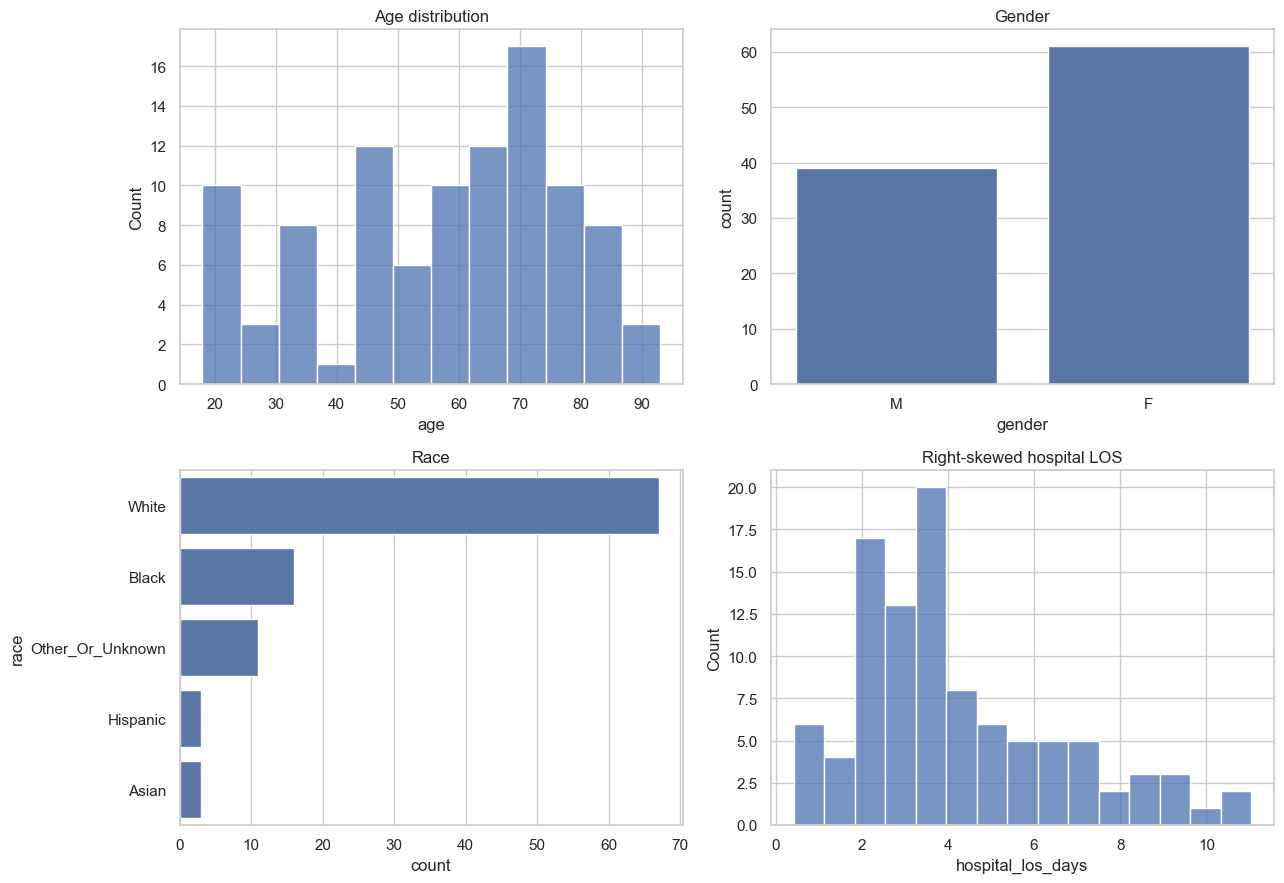

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(cohort["age"], bins=12, ax=axes[0, 0])
axes[0, 0].set_title("Age distribution")
sns.countplot(data=cohort, x="gender", ax=axes[0, 1])
axes[0, 1].set_title("Gender")
sns.countplot(data=cohort, y="race", order=cohort["race"].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Race")
sns.histplot(cohort["hospital_los_days"], bins=15, ax=axes[1, 1])
axes[1, 1].set_title("Right-skewed hospital LOS")
plt.tight_layout()
plt.show()


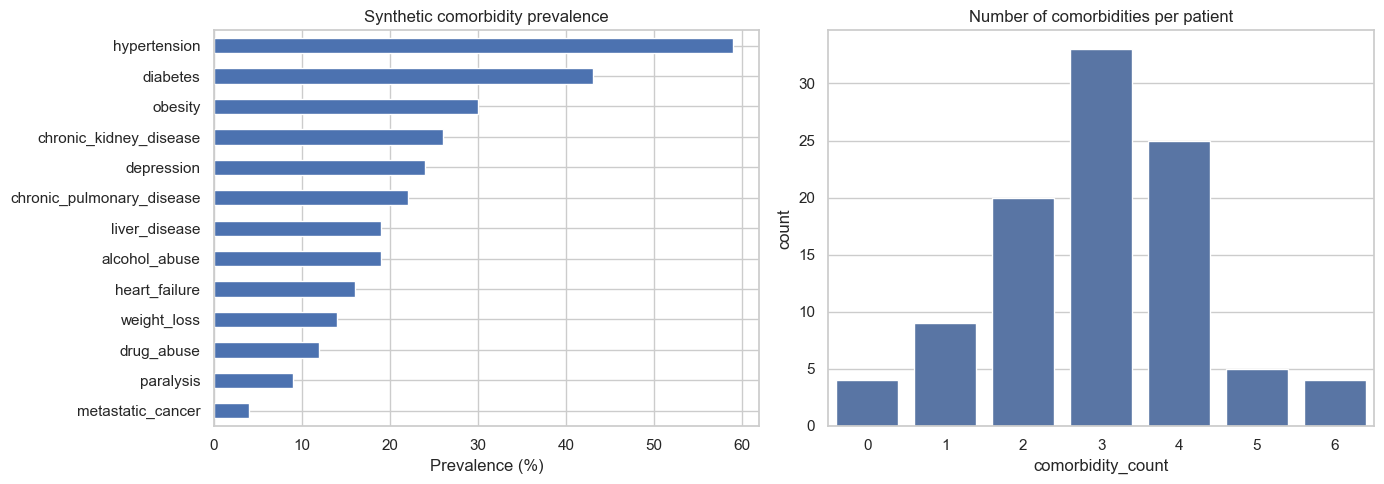

In [12]:
comorbidity_columns = [
    "heart_failure", "hypertension", "metastatic_cancer", "obesity",
    "alcohol_abuse", "depression", "paralysis", "diabetes", "weight_loss",
    "drug_abuse", "chronic_kidney_disease", "chronic_pulmonary_disease", "liver_disease"
]
prevalence = (cohort[comorbidity_columns].mean() * 100).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
prevalence.plot.barh(ax=axes[0])
axes[0].set_xlabel("Prevalence (%)")
axes[0].set_title("Synthetic comorbidity prevalence")
sns.countplot(data=cohort, x="comorbidity_count", ax=axes[1])
axes[1].set_title("Number of comorbidities per patient")
plt.tight_layout()
plt.show()


,missing_percent
albumin_first,92.0
lactate_first,88.0
pao2_first,69.0
pco2_first,69.0
inr_first,64.0
bicarbonate_first,48.0
sodium_first,46.0
potassium_first,44.0
bun_first,43.0
wbc_first,42.0


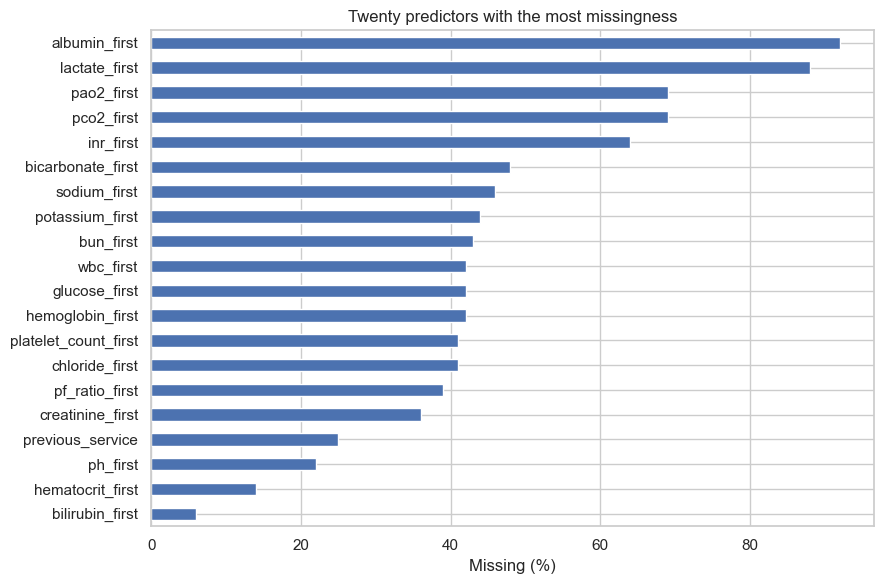

In [13]:
missingness = (cohort[predictor_columns].isna().mean() * 100).sort_values(ascending=False)
display(missingness.head(20).to_frame("missing_percent"))

missingness.head(20).sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Missing (%)")
plt.title("Twenty predictors with the most missingness")
plt.tight_layout()
plt.show()


### Missing data are not automatically “bad data”

In EHRs, a test may be absent because it was not clinically indicated, unavailable, or recorded elsewhere. Thus, missingness can carry information about care processes. This notebook uses simple imputation inside cross-validation. A production study should investigate missingness mechanisms, site differences, and whether missingness indicators are justified.


In [14]:
clinical_examples = [
    "heart_rate_first", "systolic_bp_first", "spo2_first",
    "creatinine_first", "lactate_first", "wbc_first", "hemoglobin_first"
]
cohort.groupby("readmitted_30d")[clinical_examples].median().T.rename(
    columns={0: "not_readmitted_median", 1: "readmitted_median"}
)


readmitted_30d,not_readmitted_median,readmitted_median
heart_rate_first,99.111161,104.452966
systolic_bp_first,125.768344,129.360808
spo2_first,94.175836,91.675949
creatinine_first,0.867352,0.797366
lactate_first,1.737866,1.052818
wbc_first,9.253837,7.964640
hemoglobin_first,12.196285,12.050836


## 6. Preprocessing mixed clinical data

Numerical and categorical columns require different treatment:

- Numerical: median imputation and standardization.
- Categorical: most-frequent imputation and one-hot encoding.
- Binary indicators are numeric here and pass through the numerical branch.

All learned preprocessing is inside a `Pipeline`, so each cross-validation training fold learns its own medians, category levels, and scaling parameters.


In [15]:
X = cohort[predictor_columns].copy()
y_los = cohort["hospital_los_days"].copy()
y_readmit = cohort["readmitted_30d"].astype(int).copy()

numeric_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = [c for c in X.columns if c not in numeric_columns]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])

print("Numeric predictors:", len(numeric_columns))
print("Categorical predictors:", len(categorical_columns))
print("Categorical columns:", categorical_columns)


Numeric predictors: 65
Categorical predictors: 8
Categorical columns: ['gender', 'race', 'insurance', 'marital_status', 'admission_type', 'admission_location', 'current_service', 'previous_service']


## 7. LOS regression

We compare a baseline, an interpretable regularized linear model, and a nonlinear tree ensemble. With only 100 patients, repeated cross-validation is more informative than a single lucky split—but uncertainty remains large.

Metrics:

- **MAE:** typical absolute error in days; easy to interpret.
- **RMSE:** penalizes large errors more strongly.
- **R-squared:** improvement over predicting the mean; it may be negative.

The project pipeline evaluates both raw LOS and `log1p(LOS)`. This teaching cell uses raw LOS for clarity.


In [16]:
regression_models = {
    "Dummy mean": DummyRegressor(strategy="mean"),
    "Elastic Net": ElasticNet(alpha=0.05, l1_ratio=0.3, max_iter=10000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=120, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1
    ),
}
regression_cv = RepeatedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)
regression_scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

regression_rows = []
for name, estimator in regression_models.items():
    pipeline = Pipeline([("preprocessor", clone(preprocessor)), ("model", estimator)])
    scores = cross_validate(pipeline, X, y_los, cv=regression_cv, scoring=regression_scoring)
    regression_rows.append({
        "model": name,
        "MAE_days": -scores["test_mae"].mean(),
        "RMSE_days": -scores["test_rmse"].mean(),
        "R_squared": scores["test_r2"].mean(),
    })

regression_results = pd.DataFrame(regression_rows).sort_values("MAE_days")
regression_results


,model,MAE_days,RMSE_days,R_squared
0,Dummy mean,1.850366,2.335168,-0.056763
2,Random Forest,1.864199,2.313720,-0.049394
1,Elastic Net,2.591434,3.260817,-1.134558


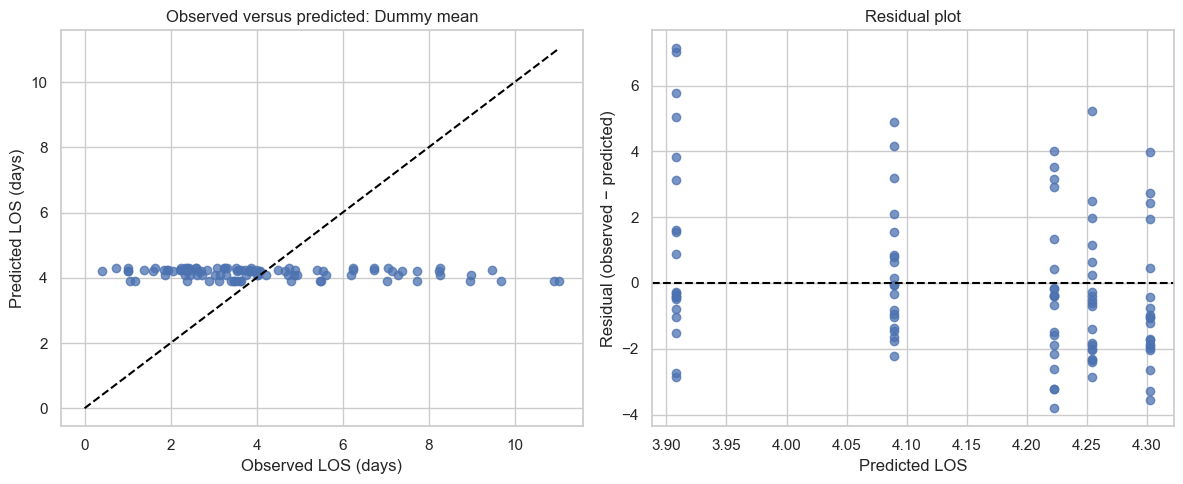

In [17]:
# Out-of-fold predictions from one 5-fold cycle make the plot easy to explain.
best_regression_name = regression_results.iloc[0]["model"]
best_regression_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", clone(regression_models[best_regression_name])),
])
single_regression_cv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE)
los_oof = cross_val_predict(best_regression_pipeline, X, y_los, cv=single_regression_cv)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_los, los_oof, alpha=.75)
limit = max(y_los.max(), los_oof.max())
axes[0].plot([0, limit], [0, limit], "--", color="black")
axes[0].set(xlabel="Observed LOS (days)", ylabel="Predicted LOS (days)",
            title=f"Observed versus predicted: {best_regression_name}")
axes[1].scatter(los_oof, y_los - los_oof, alpha=.75)
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set(xlabel="Predicted LOS", ylabel="Residual (observed − predicted)",
            title="Residual plot")
plt.tight_layout()
plt.show()


### Discussion

If the dummy model wins, that is a valid scientific result: the available sample and predictors did not support reliable improvement over a simple baseline. Never remove the baseline merely because it makes the sophisticated model look less impressive.


## 8. Thirty-day readmission classification

Readmission has 20 positive cases and 80 negative cases. Accuracy can be misleading because predicting “no readmission” for everyone gives 80% accuracy.

- **AUROC:** ranking across positive and negative cases.
- **AUPRC:** emphasizes performance on the positive class and is sensitive to prevalence.
- **Sensitivity/recall:** proportion of readmissions identified.
- **Precision:** proportion of predicted readmissions that are correct.
- **Brier score:** squared error of predicted probabilities; lower is better.
- **Calibration:** agreement between predicted risk and observed frequency.


In [18]:
classification_models = {
    "Dummy prior": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120, min_samples_leaf=3, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=1
    ),
}
classification_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=2, random_state=RANDOM_STATE
)
classification_scoring = {
    "auroc": "roc_auc",
    "auprc": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "brier": "neg_brier_score",
}

classification_rows = []
for name, estimator in classification_models.items():
    pipeline = Pipeline([("preprocessor", clone(preprocessor)), ("model", estimator)])
    scores = cross_validate(pipeline, X, y_readmit, cv=classification_cv, scoring=classification_scoring)
    classification_rows.append({
        "model": name,
        "AUROC": scores["test_auroc"].mean(),
        "AUPRC": scores["test_auprc"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "Brier_score": -scores["test_brier"].mean(),
    })

classification_results = pd.DataFrame(classification_rows).sort_values(
    ["AUROC", "AUPRC"], ascending=False
)
classification_results


,model,AUROC,AUPRC,balanced_accuracy,precision,recall,F1,Brier_score
2,Random Forest,0.921875,0.759845,0.56875,0.60,0.150,0.240000,0.120271
1,Logistic regression,0.915625,0.816720,0.80000,0.75,0.675,0.668889,0.090473
0,Dummy prior,0.500000,0.200000,0.50000,0.00,0.000,0.000000,0.160000


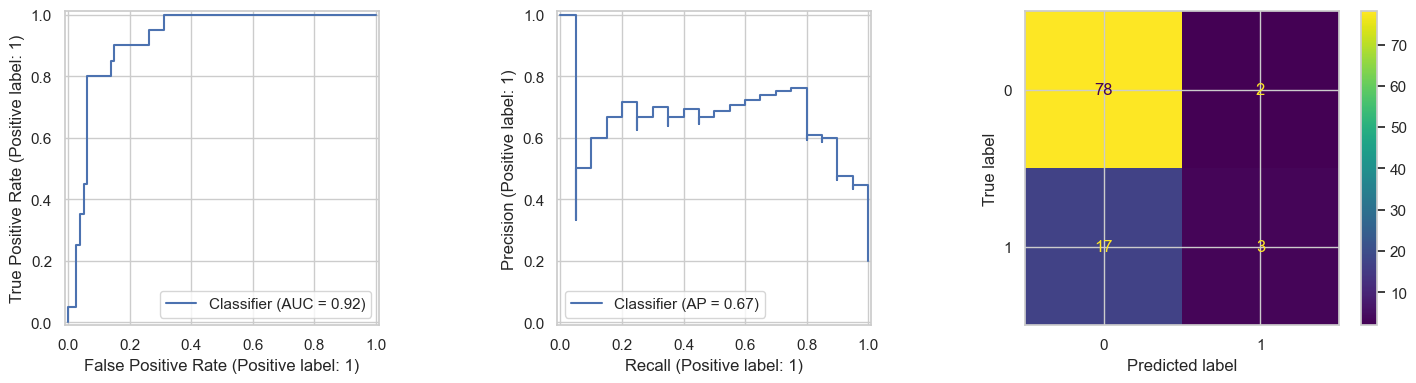

Out-of-fold AUROC: 0.921
Out-of-fold AUPRC: 0.668
Brier score: 0.122


In [19]:
best_classifier_name = classification_results.iloc[0]["model"]
best_classifier_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", clone(classification_models[best_classifier_name])),
])
single_classification_cv = RepeatedStratifiedKFold(
    n_splits=5, n_repeats=1, random_state=RANDOM_STATE
)
readmit_oof_probability = cross_val_predict(
    best_classifier_pipeline, X, y_readmit,
    cv=single_classification_cv, method="predict_proba"
)[:, 1]
readmit_oof_class = (readmit_oof_probability >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_predictions(y_readmit, readmit_oof_probability, ax=axes[0])
PrecisionRecallDisplay.from_predictions(y_readmit, readmit_oof_probability, ax=axes[1])
ConfusionMatrixDisplay.from_predictions(y_readmit, readmit_oof_class, ax=axes[2])
plt.tight_layout()
plt.show()

print("Out-of-fold AUROC:", round(roc_auc_score(y_readmit, readmit_oof_probability), 3))
print("Out-of-fold AUPRC:", round(average_precision_score(y_readmit, readmit_oof_probability), 3))
print("Brier score:", round(brier_score_loss(y_readmit, readmit_oof_probability), 3))


## 9. Calibration and gender-stratified model response

### Calibration

Discrimination asks whether the model ranks patients correctly. Calibration asks whether predicted probabilities agree with observed frequencies. For example, among patients assigned approximately 20% risk, a well-calibrated model should observe roughly 20% readmission.

The diagonal line represents perfect calibration. Points above it indicate observed readmission was more frequent than predicted; points below it indicate predicted risk was higher than observed frequency.

### Gender-stratified response and potential bias

A model can have acceptable overall performance while behaving differently across groups. We therefore examine:

- group size and outcome prevalence;
- mean predicted probability;
- AUROC and AUPRC;
- sensitivity and specificity at the same 0.50 threshold;
- Brier score and calibration curves;
- the distribution of predicted probabilities.

This is a **screening diagnostic**, not a formal fairness audit. The cohort is synthetic, contains only 100 patients, and uses a binary source field named `gender`. Small subgroup estimates are unstable, and equal metrics do not prove fairness.


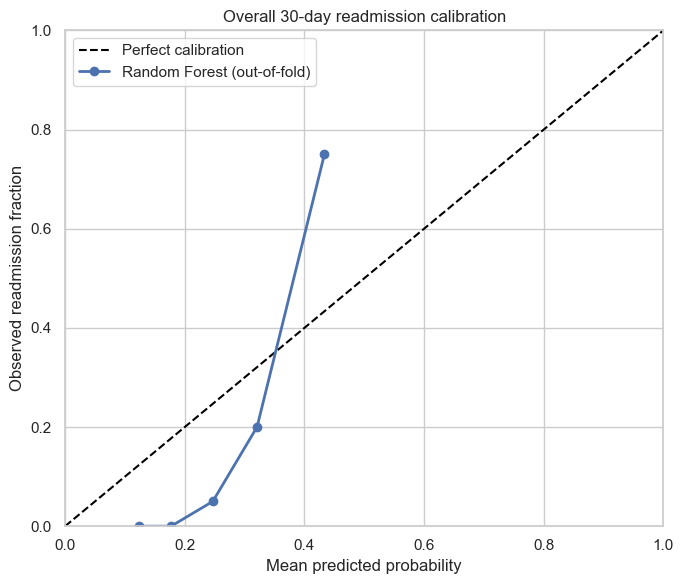

In [20]:
from sklearn.calibration import calibration_curve

# Use the out-of-fold probabilities created above, not in-sample fitted probabilities.
overall_fraction_positive, overall_mean_probability = calibration_curve(
    y_readmit,
    readmit_oof_probability,
    n_bins=5,
    strategy="quantile",
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
ax.plot(
    overall_mean_probability,
    overall_fraction_positive,
    marker="o",
    linewidth=2,
    label=f"{best_classifier_name} (out-of-fold)",
)
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed readmission fraction",
    title="Overall 30-day readmission calibration",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
def safe_auc(y_true, probability):
    """Return AUROC only when both outcome classes are present."""
    return roc_auc_score(y_true, probability) if pd.Series(y_true).nunique() == 2 else np.nan

def safe_auprc(y_true, probability):
    """Return AUPRC only when at least one positive case is present."""
    return average_precision_score(y_true, probability) if np.sum(y_true) > 0 else np.nan

gender_diagnostics = cohort[["subject_id", "gender", "readmitted_30d"]].copy()
gender_diagnostics["predicted_probability"] = readmit_oof_probability
gender_diagnostics["predicted_class_0_50"] = readmit_oof_class

gender_rows = []
for gender_value, group in gender_diagnostics.groupby("gender", dropna=False):
    y_group = group["readmitted_30d"].to_numpy()
    p_group = group["predicted_probability"].to_numpy()
    class_group = group["predicted_class_0_50"].to_numpy()

    true_negative = np.sum((y_group == 0) & (class_group == 0))
    false_positive = np.sum((y_group == 0) & (class_group == 1))
    specificity = true_negative / max(true_negative + false_positive, 1)

    gender_rows.append({
        "gender": gender_value,
        "n": len(group),
        "readmissions": int(y_group.sum()),
        "observed_prevalence": y_group.mean(),
        "mean_predicted_probability": p_group.mean(),
        "prediction_minus_prevalence": p_group.mean() - y_group.mean(),
        "AUROC": safe_auc(y_group, p_group),
        "AUPRC": safe_auprc(y_group, p_group),
        "sensitivity_at_0.50": recall_score(y_group, class_group, zero_division=0),
        "specificity_at_0.50": specificity,
        "precision_at_0.50": precision_score(y_group, class_group, zero_division=0),
        "Brier_score": brier_score_loss(y_group, p_group),
    })

gender_metric_table = pd.DataFrame(gender_rows)
gender_metric_table.style.format({
    "observed_prevalence": "{:.3f}",
    "mean_predicted_probability": "{:.3f}",
    "prediction_minus_prevalence": "{:+.3f}",
    "AUROC": "{:.3f}",
    "AUPRC": "{:.3f}",
    "sensitivity_at_0.50": "{:.3f}",
    "specificity_at_0.50": "{:.3f}",
    "precision_at_0.50": "{:.3f}",
    "Brier_score": "{:.3f}",
})


,gender,n,readmissions,observed_prevalence,mean_predicted_probability,prediction_minus_prevalence,AUROC,AUPRC,sensitivity_at_0.50,specificity_at_0.50,precision_at_0.50,Brier_score
0,F,61,9,0.148,0.254,+0.106,0.929,0.562,0.000,0.962,0.000,0.111
1,M,39,11,0.282,0.270,-0.012,0.929,0.816,0.273,1.000,1.000,0.139


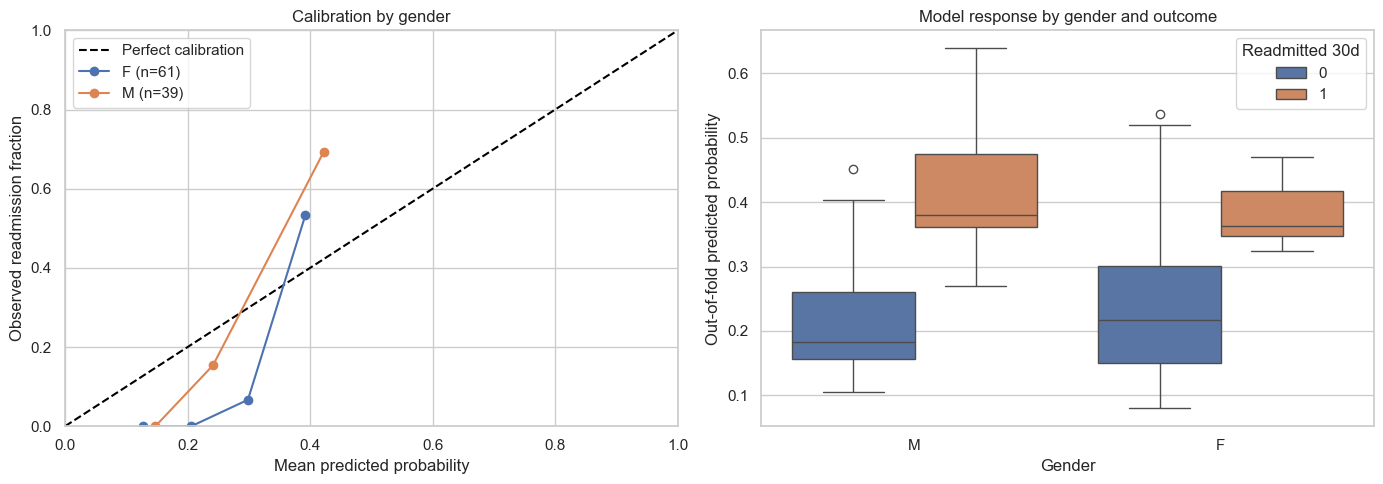

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender-specific calibration curves use quantile bins to reduce empty-bin problems.
axes[0].plot([0, 1], [0, 1], "--", color="black", label="Perfect calibration")
for gender_value, group in gender_diagnostics.groupby("gender", dropna=False):
    # With small subgroups, use no more than four bins.
    n_bins = min(4, max(2, len(group) // 10))
    fraction_positive, mean_probability = calibration_curve(
        group["readmitted_30d"],
        group["predicted_probability"],
        n_bins=n_bins,
        strategy="quantile",
    )
    axes[0].plot(
        mean_probability,
        fraction_positive,
        marker="o",
        label=f"{gender_value} (n={len(group)})",
    )
axes[0].set(
    xlabel="Mean predicted probability",
    ylabel="Observed readmission fraction",
    title="Calibration by gender",
    xlim=(0, 1),
    ylim=(0, 1),
)
axes[0].legend()

sns.boxplot(
    data=gender_diagnostics,
    x="gender",
    y="predicted_probability",
    hue="readmitted_30d",
    ax=axes[1],
)
axes[1].set(
    xlabel="Gender",
    ylabel="Out-of-fold predicted probability",
    title="Model response by gender and outcome",
)
axes[1].legend(title="Readmitted 30d")
plt.tight_layout()
plt.show()


In [23]:
# Simple absolute gaps help structure discussion but are not hypothesis tests.
if len(gender_metric_table) == 2:
    gap_summary = pd.Series({
        "absolute_prevalence_gap": gender_metric_table["observed_prevalence"].max()
            - gender_metric_table["observed_prevalence"].min(),
        "absolute_mean_prediction_gap": gender_metric_table["mean_predicted_probability"].max()
            - gender_metric_table["mean_predicted_probability"].min(),
        "absolute_sensitivity_gap": gender_metric_table["sensitivity_at_0.50"].max()
            - gender_metric_table["sensitivity_at_0.50"].min(),
        "absolute_specificity_gap": gender_metric_table["specificity_at_0.50"].max()
            - gender_metric_table["specificity_at_0.50"].min(),
        "absolute_Brier_gap": gender_metric_table["Brier_score"].max()
            - gender_metric_table["Brier_score"].min(),
    }, name="absolute_gap")
    display(gap_summary.to_frame())
else:
    print("Gap summary requires exactly two represented gender categories.")


,absolute_gap
absolute_prevalence_gap,0.134510
absolute_mean_prediction_gap,0.016279
absolute_sensitivity_gap,0.272727
absolute_specificity_gap,0.038462
absolute_Brier_gap,0.028321


### How to discuss possible bias

Differences in subgroup metrics are a reason to investigate, not proof of discrimination. Ask:

1. Are outcome prevalence and sample size different across groups?
2. Is one group systematically overpredicted or underpredicted?
3. Does the same threshold produce different sensitivity or specificity?
4. Are subgroup calibration curves meaningfully different, or simply noisy?
5. Is `gender` acting as a proxy for care processes, diagnoses, missingness, or another variable?
6. Would removing `gender` actually reduce disparity, or would correlated proxies retain it?

A proper fairness study would require a larger real-world validation cohort, clinically appropriate group definitions, confidence intervals or bootstrap distributions, intersectional analysis, temporal and external validation, and stakeholder-defined harm criteria.


## 10. Interpretation: permutation importance

Permutation importance shuffles one feature at a time and measures how much fitted-model performance worsens. It can be unstable with correlated features and small samples. It is **not** evidence that the feature causes the outcome.

For a rigorous estimate, importance should be calculated on held-out data or within resampling. The simple demonstration below fits the model to the full synthetic cohort and is explicitly descriptive.


,mean_AUROC_decrease
chronic_kidney_disease,0.014625
age,0.000000
hematocrit_first,0.000000
hemoglobin_first,0.000000
wbc_first,0.000000
bun_first,0.000000
sodium_first,0.000000
platelet_count_first,0.000000
lactate_first,0.000000
creatinine_first,0.000000


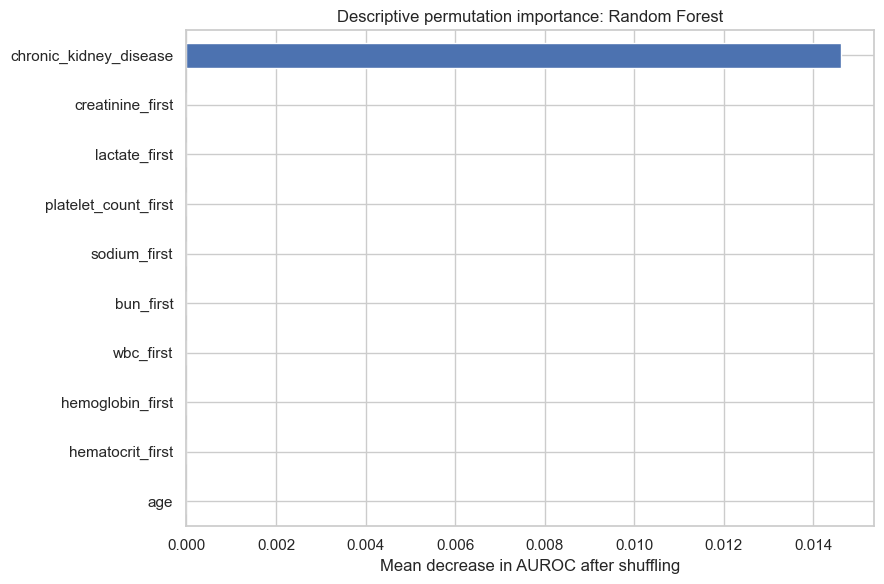

In [24]:
best_classifier_pipeline.fit(X, y_readmit)
importance_result = permutation_importance(
    best_classifier_pipeline, X, y_readmit,
    scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE
)
importance = pd.Series(
    importance_result.importances_mean, index=predictor_columns,
    name="mean_AUROC_decrease"
).sort_values(ascending=False)

display(importance.head(10).to_frame())
importance.head(10).sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Mean decrease in AUROC after shuffling")
plt.title(f"Descriptive permutation importance: {best_classifier_name}")
plt.tight_layout()
plt.show()


## 11. SHAP interpretation for the readmission classifier

SHAP (SHapley Additive exPlanations) distributes a model prediction across its input features. It supports three useful views:

- **Global importance:** which transformed features have the largest average absolute SHAP values?
- **Global direction and distribution:** for each feature, do high or low values tend to push predictions toward or away from readmission?
- **Local explanation:** which features pushed one patient's prediction above or below the model's baseline prediction?

For a beginner-friendly and computationally efficient demonstration, we fit a Random Forest to the full synthetic cohort and use SHAP's tree explainer. The preprocessing pipeline is fitted first, and SHAP explains the resulting imputed, standardized, and one-hot-encoded columns.

> This section is descriptive, not a performance estimate. The model is fitted to all 100 synthetic patients only to demonstrate interpretation. SHAP explains this fitted model; it does not establish causality, treatment effects, clinical utility, or generalizability.


In [25]:
import shap

# Fit the preprocessing and Random Forest demonstration pipeline.
shap_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])
shap_pipeline.fit(X, y_readmit)

# SHAP operates on the model's actual numeric input after preprocessing.
fitted_preprocessor = shap_pipeline.named_steps["preprocessor"]
fitted_classifier = shap_pipeline.named_steps["model"]
X_transformed = fitted_preprocessor.transform(X)
transformed_feature_names = fitted_preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=transformed_feature_names,
    index=X.index,
)

explainer = shap.Explainer(fitted_classifier, X_transformed_df)
raw_shap = explainer(X_transformed_df)

# Binary classifiers may return either:
#   (patients, features, classes), or
#   (patients, features) for the positive class.
if raw_shap.values.ndim == 3:
    positive_class_shap = raw_shap[:, :, 1]
else:
    positive_class_shap = raw_shap

print("SHAP version:", shap.__version__)
print("Transformed feature matrix:", X_transformed_df.shape)
print("Positive-class SHAP matrix:", positive_class_shap.values.shape)


SHAP version: 0.46.0
Transformed feature matrix: (100, 102)
Positive-class SHAP matrix: (100, 102)


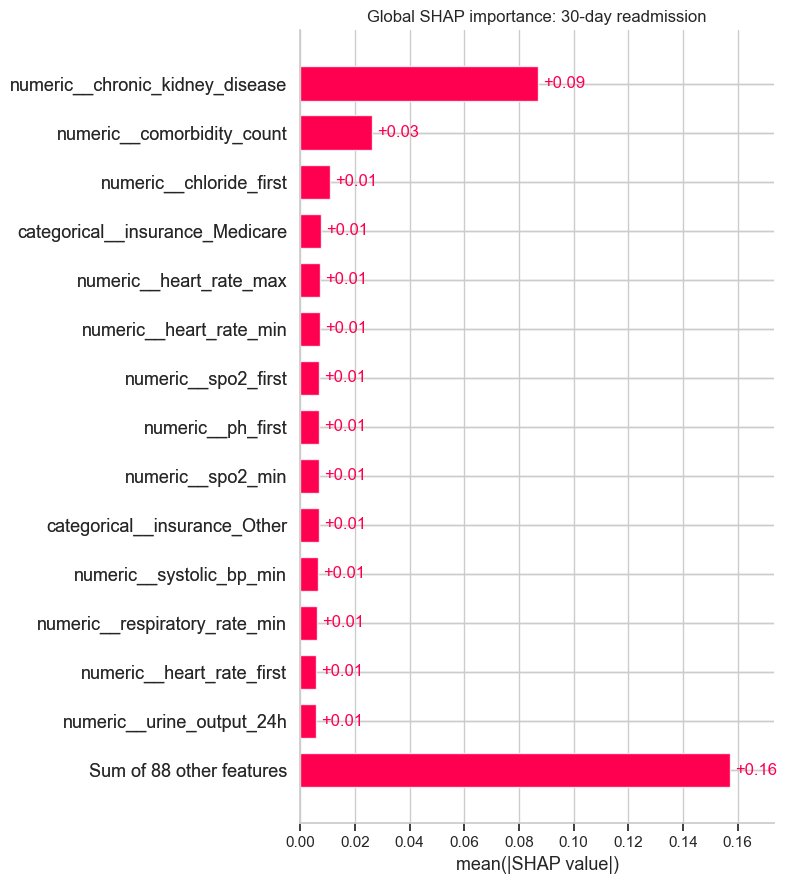

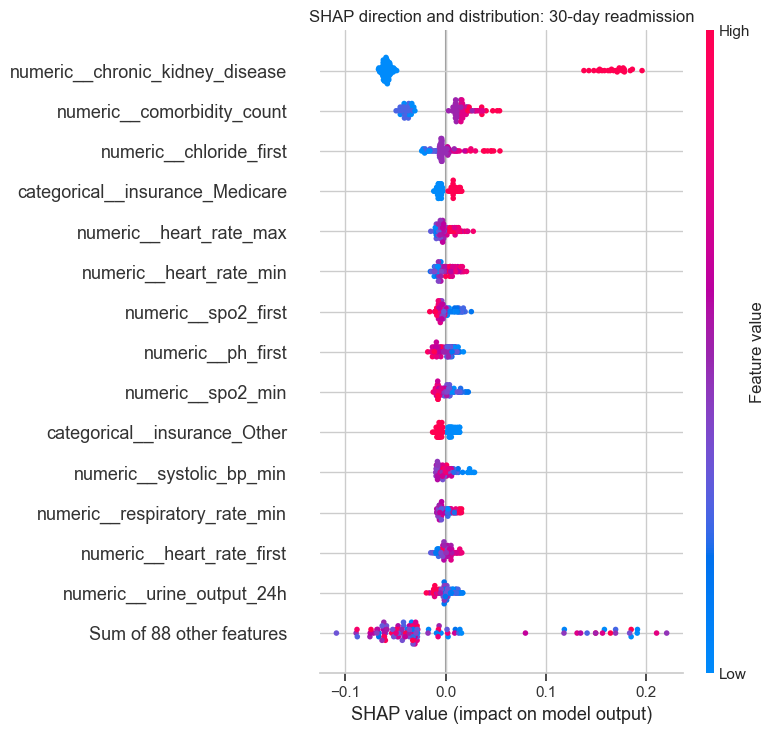

In [26]:
# Global importance: mean absolute contribution to predicted readmission probability.
shap.plots.bar(positive_class_shap, max_display=15, show=False)
plt.title("Global SHAP importance: 30-day readmission")
plt.tight_layout()
plt.show()

# Beeswarm: color represents the transformed feature value.
# Horizontal position shows whether the feature pushed prediction higher or lower.
shap.plots.beeswarm(positive_class_shap, max_display=15, show=False)
plt.title("SHAP direction and distribution: 30-day readmission")
plt.tight_layout()
plt.show()


Example synthetic subject_id: 90000096
Fitted readmission probability: 0.815
Observed synthetic outcome: 1


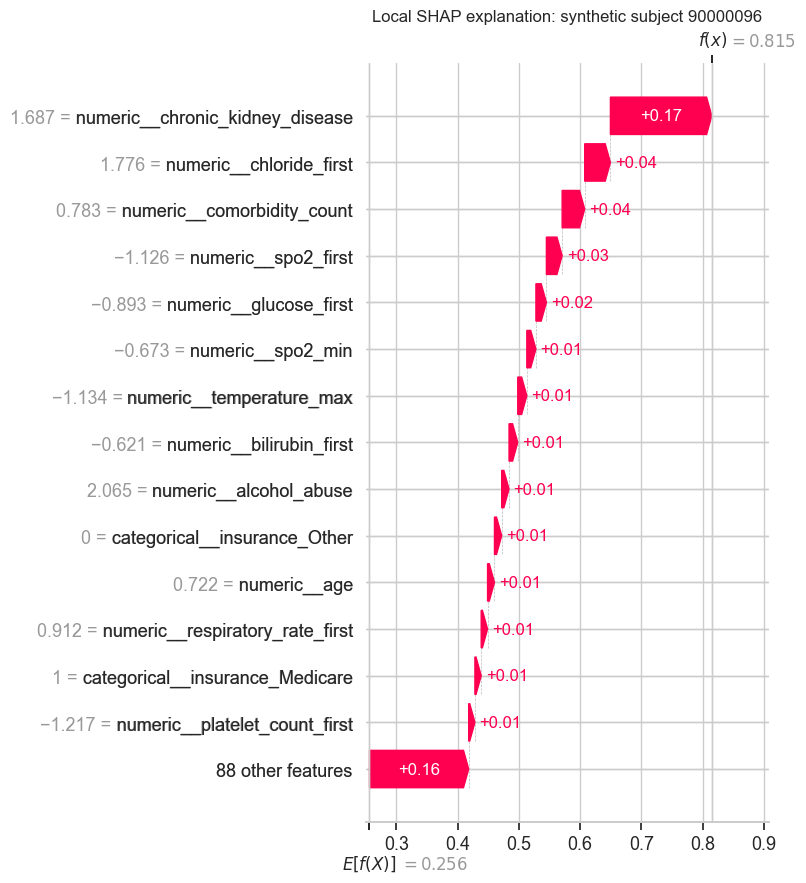

In [27]:
# Explain the patient with the highest fitted readmission probability.
fitted_probability = shap_pipeline.predict_proba(X)[:, 1]
example_position = int(np.argmax(fitted_probability))
example_subject = int(cohort.iloc[example_position]["subject_id"])

print("Example synthetic subject_id:", example_subject)
print("Fitted readmission probability:", round(float(fitted_probability[example_position]), 3))
print("Observed synthetic outcome:", int(y_readmit.iloc[example_position]))

shap.plots.waterfall(
    positive_class_shap[example_position],
    max_display=15,
    show=False,
)
plt.title(f"Local SHAP explanation: synthetic subject {example_subject}")
plt.tight_layout()
plt.show()


### How to read the SHAP plots

1. The bar plot ranks transformed inputs by their average absolute contribution.
2. In the beeswarm plot, points to the right increase the model's predicted probability for the positive class; points to the left decrease it.
3. The waterfall begins at the model's baseline output and adds positive and negative feature contributions for one patient.
4. One-hot encoded categories appear as separate transformed features.
5. Correlated clinical variables can divide or exchange attribution, so rankings may change across samples or model specifications.

### Important limitations

- These explanations are based on 100 synthetic patients.
- The full-cohort fit is for teaching interpretation, not unbiased evaluation.
- SHAP values explain model behavior, including model errors and synthetic-generation artifacts.
- A large SHAP value does not mean a variable caused readmission.
- Protected characteristics require careful governance and fairness analysis; they should not be interpreted as biological causes.


## 12. Interpretable coefficient directions

Logistic-regression coefficients describe change in log odds after preprocessing. For standardized numerical variables, a positive coefficient means higher standardized values are associated with higher predicted readmission odds, conditional on other variables. One-hot categorical coefficients compare a category with the encoded reference structure.

Coefficient magnitude depends on scaling and coding. Direction is association in this fitted synthetic model—not causality.


In [28]:
logistic_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logistic_pipeline.fit(X, y_readmit)
transformed_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = pd.DataFrame({
    "transformed_feature": transformed_names,
    "log_odds_coefficient": logistic_pipeline.named_steps["model"].coef_[0],
})
coefficients["direction"] = np.where(
    coefficients["log_odds_coefficient"] >= 0,
    "higher predicted odds", "lower predicted odds"
)
coefficients.reindex(
    coefficients["log_odds_coefficient"].abs().sort_values(ascending=False).index
).head(15)


,transformed_feature,log_odds_coefficient,direction
31,numeric__chronic_kidney_disease,2.230658,higher predicted odds
34,numeric__comorbidity_count,0.921491,higher predicted odds
56,numeric__gcs_eyes_first,0.619613,higher predicted odds
101,categorical__previous_service_SURG,-0.490991,lower predicted odds
42,numeric__platelet_count_first,-0.439230,lower predicted odds
37,numeric__pf_ratio_first,-0.405980,lower predicted odds
55,numeric__gcs_verbal_first,-0.404113,lower predicted odds
25,numeric__alcohol_abuse,0.400547,higher predicted odds
49,numeric__chloride_first,0.360146,higher predicted odds
58,numeric__urine_output_24h,-0.358484,lower predicted odds


## 13. Common mistakes checklist

- Treating rows in `labevents` as independent patients.
- Joining two one-to-many tables before aggregation.
- Randomly splitting rows when one patient has multiple admissions.
- Imputing or scaling before cross-validation.
- Including discharge fields in an admission-time LOS model.
- Using a future admission date as a readmission predictor.
- Reporting accuracy alone for an imbalanced outcome.
- Selecting a model using the test set.
- Interpreting feature importance as causality.
- Claiming clinical utility from a small synthetic cohort.
- Ignoring subgroup sample sizes, calibration, temporal drift, and external validation.


## 14. Hands-on exercises

### Beginner

1. Compute age-group counts for 18–39, 40–59, 60–79, and 80+.
2. Find the three most prevalent comorbidities.
3. Compare median creatinine by readmission status.
4. Explain why `dischtime` cannot predict LOS at admission time.

### Intermediate

5. Add `HistGradientBoostingRegressor` and `HistGradientBoostingClassifier`.
6. Compare raw LOS with `np.log1p(LOS)` and convert predictions back using `np.expm1`.
7. Change the classification threshold from 0.50 to 0.30 and compare sensitivity and precision.
8. Remove intervention features and examine how performance changes.

### Advanced discussion

9. How would patient-level grouped CV change if several index admissions per patient were included?
10. How would you perform temporal validation?
11. Which fairness questions are appropriate, and why are 100 synthetic patients insufficient?
12. What additional privacy evaluation would be required before releasing synthetic data learned from real records?


## 15. Take-home conclusions

1. Define the cohort, row grain, outcome, prediction time, and observation window before modeling.
2. Preserve source provenance even when creating wide derived features.
3. Aggregate one-to-many tables before joining to an admission-level cohort.
4. Keep preprocessing inside cross-validation.
5. Always compare against a simple baseline.
6. Choose metrics that reflect the clinical task and class prevalence.
7. Treat missingness and measurement frequency as clinical-process phenomena.
8. Predictive importance is not causal evidence.
9. Small synthetic demonstrations are excellent for learning but cannot establish clinical utility.

### Reproducibility

Run the complete project from PowerShell:

```powershell
cd synthetic_cohort_100
python run_pipeline.py
pytest -q
```

The detailed provenance, validation results, and final model results are available under `outputs/`.
